In [3]:
from shapely.geometry import Point
from shapely.ops import transform
import pyproj
from rasterstats import zonal_stats
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from metloom.pointdata import SnotelPointData
import pandas as pd
from datetime import datetime
import os


In [4]:
# Path to the folder containing raster files
path = "C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/"
files = os.listdir(path)
snowdepths = []

snowdepths = [os.path.join(path, f) for f in os.listdir(path) if f.endswith("SD_V01.0.tif")]

    
    
print(snowdepths)

['C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20220217_SD_V01.0.tif', 'C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20220317_SD_V01.0.tif', 'C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20220407_SD_V01.0.tif', 'C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20221208_SD_V01.0.tif', 'C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20230209_SD_V01.0.tif', 'C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20230316_SD_V01.0.tif', 'C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20230405_SD_V01.0.tif', 'C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20231113_SD_V01.0.tif', 'C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20231228_SD_V01.0.tif', 'C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20240115_SD_V01.0.tif', 'C:/Users

In [6]:

# Your original lat/lon point
point_wgs84 = Point(-115.665990, 43.932067)


# Define source and target CRS
crs_wgs84 = pyproj.CRS('EPSG:4326')
crs_32611 = pyproj.CRS('EPSG:32611')

# Transformer from WGS84 to UTM Zone 11N
project = pyproj.Transformer.from_crs(crs_wgs84, crs_32611, always_xy=True).transform

# Transform point to raster CRS
point_utm = transform(project, point_wgs84)

# Create buffer in meters (e.g., 1000m = 1km)
buffer_radius = 1  # meters
buffer_utm = point_utm.buffer(buffer_radius)

print(buffer_utm)  # This polygon is in EPSG:32611 coordinates (meters)


POLYGON ((607076.3997817099 4865192.632881377, 607076.3949664366 4865192.534864237, 607076.3805669902 4865192.437791055, 607076.3567220456 4865192.3425966995, 607076.3236612424 4865192.250197944, 607076.2817029742 4865192.16148464, 607076.2312513222 4865192.077311144, 607076.1727921632 4865191.998488093, 607076.1068884911 4865191.925774596, 607076.0341749941 4865191.859870924, 607075.9553519429 4865191.801411765, 607075.8711784467 4865191.750960113, 607075.7824651422 4865191.709001845, 607075.6900663872 4865191.675941041, 607075.594872032 4865191.652096096, 607075.4977988502 4865191.63769665, 607075.3997817099 4865191.632881377, 607075.3017645696 4865191.63769665, 607075.2046913878 4865191.652096096, 607075.1094970326 4865191.675941041, 607075.0170982776 4865191.709001845, 607074.9283849731 4865191.750960113, 607074.8442114769 4865191.801411765, 607074.7653884257 4865191.859870924, 607074.6926749287 4865191.925774596, 607074.6267712566 4865191.998488093, 607074.5683120976 4865192.07731

In [7]:
# Convert Shapely polygon to GeoJSON-like dict
geom = mapping(buffer_utm)

results = []

for raster_file in snowdepths:
    try:
        stats = zonal_stats(geom, raster_file, stats=["min", "max", "median", "std"])
        results.append({
            "Filename": os.path.basename(raster_file),
            "Min": stats[0]["min"],
            "Max": stats[0]["max"],
            "Median": stats[0]["median"],
            "Std": stats[0]["std"]
        })
    except Exception as e:
        print(f"Error with {raster_file}: {e}")

# Print min/max
#for fname, stat in results.items():
    #print(f"{fname} --> Min: {stat['min']}, Max: {stat['max']}, Mean: {stat['mean']}, Std: {stat['std']}")

print(results)    

C:\Users\RDCRLSMC\AppData\Local\miniconda3\envs\iceroad\lib\site-packages\rasterstats\io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


Error with C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20221208_SD_V01.0.tif: Read or write failed. C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20221208_SD_V01.0.tif, band 1: IReadBlock failed at X offset 0, Y offset 11357: TIFFReadEncodedStrip() failed.
Error with C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20230209_SD_V01.0.tif: Read or write failed. C:/Users/RDCRLSMC/Desktop/SNEX_MCS_Lidar_1-20250512_221456/SNEX_MCS_Lidar_20230209_SD_V01.0.tif, band 1: IReadBlock failed at X offset 0, Y offset 11357: TIFFReadEncodedStrip() failed.
[{'Filename': 'SNEX_MCS_Lidar_20220217_SD_V01.0.tif', 'Min': 1.2794189453125, 'Max': 1.3839111328125, 'Median': 1.3515625, 'Std': 0.026912706599630385}, {'Filename': 'SNEX_MCS_Lidar_20220317_SD_V01.0.tif', 'Min': 1.315185546875, 'Max': 1.355224609375, 'Median': 1.335693359375, 'Std': 0.011277383686866673}, {'Filename': 'SNEX_MCS_Lidar_20220407_SD_V01.0.tif', 'Min': 0.

In [8]:
# Convert to DataFrame
df = pd.DataFrame(results)

# Optional: Extract date from filename and add a column
df["Date"] = pd.to_datetime(df["Filename"].str.extract(r"(\d{8})")[0], format="%Y%m%d")

# Optional: Sort by date
df = df.sort_values("Date")

print(df)

                                Filename       Min       Max    Median  \
0   SNEX_MCS_Lidar_20220217_SD_V01.0.tif  1.279419  1.383911  1.351562   
1   SNEX_MCS_Lidar_20220317_SD_V01.0.tif  1.315186  1.355225  1.335693   
2   SNEX_MCS_Lidar_20220407_SD_V01.0.tif  0.885864  1.026123  0.931763   
3   SNEX_MCS_Lidar_20230316_SD_V01.0.tif  2.296021  2.345459  2.318481   
4   SNEX_MCS_Lidar_20230405_SD_V01.0.tif  2.660889  2.737061  2.709717   
5   SNEX_MCS_Lidar_20231113_SD_V01.0.tif -0.047119  0.000732 -0.029297   
6   SNEX_MCS_Lidar_20231228_SD_V01.0.tif  0.422974  0.531982  0.474365   
7   SNEX_MCS_Lidar_20240115_SD_V01.0.tif  1.116333  1.213623  1.166992   
8   SNEX_MCS_Lidar_20240213_SD_V01.0.tif  1.161255  1.223389  1.197388   
9   SNEX_MCS_Lidar_20240315_SD_V01.0.tif  1.839600  1.898193  1.864990   
10  SNEX_MCS_Lidar_20240418_SD_V01.0.tif  1.225708  1.384521  1.282959   

         Std       Date  
0   0.026913 2022-02-17  
1   0.011277 2022-03-17  
2   0.041301 2022-04-07  
3   0.0

In [9]:
snotel_point = SnotelPointData("637:ID:SNTL", "MCS")  # define the snotel ID

# get the daily data for the snotel site for the specified date range and variables
df_SNOTEL = snotel_point.get_daily_data(
    datetime(2022, 2, 1), datetime(2024, 4, 30),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

df_SNOTEL["SNOWDEPTH (m)"] = df_SNOTEL["SNOWDEPTH"] * 0.0254  # convert snow depth from inches to meters
#df.to_csv("snotel_data.csv", index=False)  # save the data to a csv file

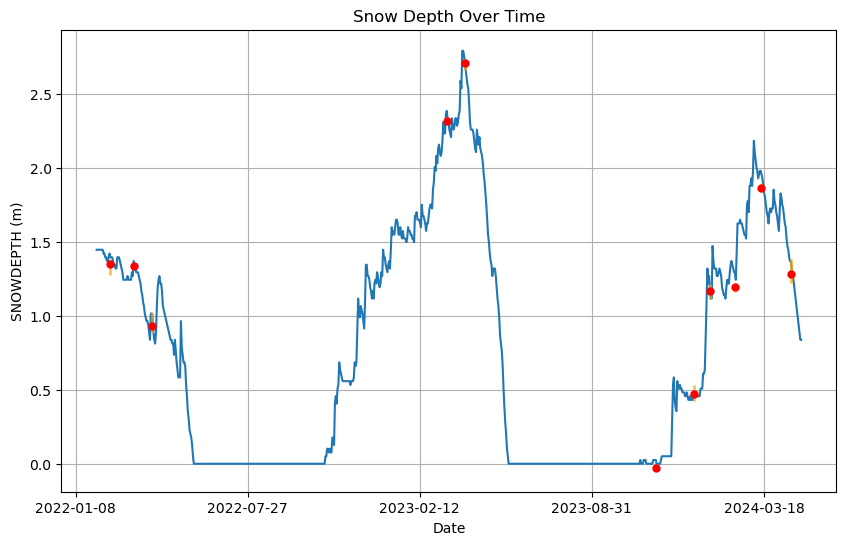

In [10]:
# Extract the datetime index and SNOWDEPTH (m) values
dates = df_SNOTEL.index.get_level_values(0)
snowdepth = df_SNOTEL['SNOWDEPTH (m)']

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dates, snowdepth, linestyle='-')
for _, row in df.iterrows():
    plt.vlines(x=row["Date"], ymin=row["Min"], ymax=row["Max"], color='orange', alpha=0.7, linewidth=2)
    plt.plot(row["Date"], row["Median"], 'o', color='red', markersize=5)

plt.xlabel('Date')
plt.ylabel('SNOWDEPTH (m)')
plt.title('Snow Depth Over Time')
plt.grid(True)

# Format the x-axis to show only 5 labels
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))

plt.show()